In [21]:
import pandas as pd
import numpy as np
import random

random.seed(42)
np.random.seed(42)

pain_descriptor_categories = {
    "Temporal": ["flickering", "quivering", "pulsing", "throbbing", "beating", "pounding"],
    "Spatial": ["jumping", "flashing", "shooting"],
    "Punctate_Pressure": ["pricking", "boring", "drilling", "stabbing", "lancinating"],
    "Incisive_Pressure": ["sharp", "cutting", "lacerating"],
    "Constrictive_Pressure": ["pinching", "pressing", "gnawing", "cramping", "crushing"],
    "Traction_Pressure": ["tugging", "pulling", "wrenching"],
    "Thermal": ["hot", "boring", "scalding", "searing"],
    "Brightness": ["tingling", "itchy", "smarting", "stinging"],
    "Dullness": ["dull", "sore", "hurting", "aching", "heavy"],
    "Sensory_Misc": ["tender", "taut", "rasping", "splitting"],
    "Tension": ["tiring", "exhausting"],
    "Autonomic": ["sickening", "suffocating"],
    "Fear": ["fearful", "frightful", "terrifying"],
    "Punishment": ["punishing", "gruelling", "cruel", "vicious", "killing"],
    "Affective_Eval_Sensory": ["wretched", "blinding"],
    "Evaluative": ["annoying", "troublesome", "miserable", "intense", "unbearable"],
    "Sensory": ["spreading", "radiating", "penetrating", "piercing"],
    "Sensory2": ["tight", "numb", "drawing", "squeezing", "tearing"],
    "Sensory3": ["cool", "cold", "freezing"],
    "Affective": ["nagging", "nauseating", "agonizing", "dreadful", "torturing"]
}

pain_words = ["Mild", "Discomforting", "Distressing", "Horrible", "Excruciating"]
pain_scores_map = {word: i + 1 for i, word in enumerate(pain_words)}
pain_pattern_options = ["continuous steady constant", "rhythmic periodic intermittent", "brief momentary transient"]
modifying_factors = ['liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp', 'weather_changes', 'massage',
                     'pressure', 'no_movement', 'movement', 'sleep', 'lying_down', 'distraction', 'urination',
                     'tension', 'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise', 'fatigue']
interference_fields = ['Activity', 'Enjoy', 'Mood', 'Relate', 'Sleep', 'Walk', 'Work']

def classify_pain_type(tumor_sitology, pain_projection, irradiation_site, osteoarthropathy):
    if "Apex" in tumor_sitology or "Radiates" in pain_projection:
        return "neuropathic"
    elif "Localized" in pain_projection or any(area in osteoarthropathy for area in ['elbows', 'knees', 'wrists']):
        return "nociceptive"
    else:
        return "nociceptive"

def assign_tipo_dolore(total_score):
    return "chronic" if total_score >= 65 else "acute"

def distribute_score(target_score, n_categories):
    """Distribute score across categories while keeping each value between 1 and 5."""
    scores = [1] * n_categories
    remaining = target_score - n_categories
    while remaining > 0:
        for i in range(n_categories):
            if scores[i] < 5 and remaining > 0:
                scores[i] += 1
                remaining -= 1
    random.shuffle(scores)
    return scores

def generate_patient(pid, score_range):
    data = {'ID': pid}
    data['Sex'] = random.choice(['M', 'F'])
    data['Age'] = random.randint(18, 80)
    data['BPM'] = random.randint(60, 120)

    total_target_score = random.randint(*score_range)
    categories = list(pain_descriptor_categories.keys())
    n_cats = len(categories)
    scores = distribute_score(total_target_score, n_cats)

    total_score = 0
    for cat, score in zip(categories, scores):
        word = random.choice(pain_descriptor_categories[cat])
        data[cat] = word
        data[f"{cat}_Score"] = score
        total_score += score

    data["Pain_Pattern"] = random.choice(pain_pattern_options)

    for mod in modifying_factors:
        data[mod] = random.choice(["increase", "decrease"])

    for label in ['Pain_Now', 'Pain_Worst', 'Pain_Least', 'Worst_Toothache', 'Worst_Headache', 'Worst_Stomachache']:
        word = random.choice(pain_words)
        data[label] = word
        data[f"{label}_Score"] = pain_scores_map[word]

    for interference in interference_fields:
        data[interference] = np.clip(np.random.normal(loc=5, scale=2), 0, 10).round(0)

    # Clinical info
    data["surgery_site"] = random.choice(["Post-thoracotomy incision site", "Lobectomy scar", "None"])
    data["tumor_sitology"] = random.choice(["Apex of the right lung", "Central lung mass", "Apex of the left lung"])
    data["irradiation_site"] = random.choice(["Radiation therapy left lung", "None", "Radiation therapy right lung"])
    data["osteoarthropathy"] = random.choice(["Pain in elbows and knees", "Wrist osteoarthropathy", "None"])
    data["pain_projection"] = random.choice(["Radiates along C7-T1", "Localized with no transmission"])

    data["pain_type"] = classify_pain_type(data["tumor_sitology"], data["pain_projection"],
                                           data["irradiation_site"], data["osteoarthropathy"])
    data["Total_Pain_Score"] = total_score
    data["Tipo_dolore"] = assign_tipo_dolore(total_score)
    data["PRI"] = total_score

    return data

ranges = {
    "low": (10, 30),
    "medium": (31, 64),
    "high": (65, 78)
}
per_range = 500 // 3
dataset = []

pid = 1
for r in ranges.values():
    for _ in range(per_range):
        dataset.append(generate_patient(pid, r))
        pid += 1

df = pd.DataFrame(dataset)
df.to_csv("McGill_Pain_Questionnaire_MEDICINEGPT.csv", index=False)
print("Dataset generated and saved as 'lung_cancer_pain_data.csv'. Total rows:", len(df))


Dataset generated and saved as 'lung_cancer_pain_data.csv'. Total rows: 498


In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import statsmodels.api as sm
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
import prince

import os
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

# Scoring 1 : tre fasce

In [23]:
dataset_path = f"../dataset/McGill_Pain_Questionnaire_DOCTORAI.csv"
df = pd.read_csv(dataset_path)

In [24]:
df['scoring_1'] = df['PRI'].apply(lambda x: 1 if x < 26 else (2 if x <= 46 else 3))
df['scoring_1'] =df['scoring_1'].astype('category')
df['Sex n']=df['Sex'].apply(lambda x: 0 if x=='F' else 1)

In [25]:
df['scoring_1'].value_counts()

scoring_1
3    259
1    122
2    117
Name: count, dtype: int64

In [26]:
table = pd.crosstab(df['scoring_1'], df['Sex'])
chi2, p, dof, expected = stats.chi2_contingency(table)
print("Chi-quadro:", chi2, "p-value:", p)


group1 = df[df['scoring_1'] == 1]['Age']
group2 = df[df['scoring_1'] == 2]['Age']
group3 = df[df['scoring_1'] == 3]['Age']
t_stat_12, p_value_12 = stats.ttest_ind(group1, group2, equal_var=False)
print("T-test 1 vs 2: statistic:", t_stat_12, "p-value:", p_value_12)
t_stat_13, p_value_13 = stats.ttest_ind(group1, group3, equal_var=False)
print("T-test 1 vs 3: statistic:", t_stat_13, "p-value:", p_value_13)
t_stat_23, p_value_23 = stats.ttest_ind(group2, group3, equal_var=False)
print("T-test 2 vs 3: statistic:", t_stat_23, "p-value:", p_value_23)

Chi-quadro: 2.5897293856050645 p-value: 0.27393492719124
T-test 1 vs 2: statistic: -0.7444078982675942 p-value: 0.4573730527303205
T-test 1 vs 3: statistic: -1.6877735329819266 p-value: 0.09272086747216998
T-test 2 vs 3: statistic: -0.7647471439410765 p-value: 0.44523163020961987


In [27]:
table_sex = pd.crosstab(df['scoring_1'], df['Sex'], margins=True)
table_sex_percent = table_sex.div(table_sex.loc['All'], axis=1) * 100  # Percentuali per colonna

age_stats = df.groupby('scoring_1')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
age_stats['IQR'] = df.groupby('scoring_1')['Age'].quantile(0.75) - df.groupby('scoring_1')['Age'].quantile(0.25)

chi2, p, dof, expected = stats.chi2_contingency(table_sex.iloc[:-1, :-1])  # Rimuoviamo la riga 'All' per il test

group1 = df[df['scoring_1'] == 1]['Age']
group2 = df[df['scoring_1'] == 2]['Age']
group3 = df[df['scoring_1'] == 3]['Age']
t_stat_12, p_value_12 = stats.ttest_ind(group1, group2, equal_var=False)
t_stat_13, p_value_13 = stats.ttest_ind(group1, group3, equal_var=False)
t_stat_23, p_value_23 = stats.ttest_ind(group2, group3, equal_var=False)

summary_table = pd.DataFrame({
    'Scoring Group': [1, 2, 3],
    'N (Totale)': age_stats['count'].values,
    'Età Media (SD)': [f"{m:.1f} ({s:.1f})" for m, s in zip(age_stats['mean'], age_stats['std'])],
    'Mediana (IQR)': [f"{med:.1f} ({iqr:.1f})" for med, iqr in zip(age_stats['median'], age_stats['IQR'])],
    'Maschi (%)': [f"{table_sex_percent.loc[i, 'M']:.1f}%" for i in range(1, 4)],
    'Femmine (%)': [f"{table_sex_percent.loc[i, 'F']:.1f}%" for i in range(1, 4)]
})

print(summary_table.to_string(index=False))
print(f"Chi-quadro per il sesso tra i gruppi: χ² = {chi2:.2f}, p-value = {p:.3f}")
print(f"T-test età tra 1 e 2: t = {t_stat_12:.2f}, p-value = {p_value_12:.3f}")
print(f"T-test età tra 1 e 3: t = {t_stat_13:.2f}, p-value = {p_value_13:.3f}")
print(f"T-test età tra 2 e 3: t = {t_stat_23:.2f}, p-value = {p_value_23:.3f}")

 Scoring Group  N (Totale) Età Media (SD) Mediana (IQR) Maschi (%) Femmine (%)
             1         122    46.9 (17.2)   44.0 (24.0)      21.5%       27.7%
             2         117    48.6 (18.0)   47.0 (33.0)      24.6%       22.3%
             3         259    50.1 (17.9)   50.0 (29.0)      53.8%       50.0%
Chi-quadro per il sesso tra i gruppi: χ² = 2.59, p-value = 0.274
T-test età tra 1 e 2: t = -0.74, p-value = 0.457
T-test età tra 1 e 3: t = -1.69, p-value = 0.093
T-test età tra 2 e 3: t = -0.76, p-value = 0.445


/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_15742/2480631654.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('scoring_1')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_15742/2480631654.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats['IQR'] = df.groupby('scoring_1')['Age'].quantile(0.75) - df.groupby('scoring_1')['Age'].quantile(0.25)


In [28]:
from sklearn.metrics import classification_report
import re
model_dir = "scoring_1 - model , medicinegpt"
os.makedirs(model_dir, exist_ok=True)


X = df[['Age', 'Sex n','BPM','Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score' ]]

y = df['scoring_1'].astype(int) - 1  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  # Salta righe che non contengono numeri validi

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")




Performing Stepwise Regression for SVM...
Variabili selezionate per SVM: ['Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Sensory_Misc_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score']
Modelli per SVM salvati in scoring_1 - model , medicinegpt/SVM_all_features.pkl e scoring_1 - model , medicinegpt/SVM_selected_features.pkl
Accuracy (All features): 0.75
Accuracy (Stepwise features): 0.93
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.61      0.92      0.73        25
           1       0.00      0.00      0.00        23
           2       0.87      1.00      0.93        52

    accuracy                           0.75       100
   macro avg       0.49      0.64      0.55       100
weighted avg       0.60      0.75      0.67       100

Classification Report (Stepwise features):
      

/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/

Variabili selezionate per Multinomial Logistic Regression: ['Age', 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Sensory_Misc_Score', 'Autonomic_Score', 'Punishment_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score']
Modelli per Multinomial Logistic Regression salvati in scoring_1 - model , medicinegpt/Multinomial Logistic Regression_all_features.pkl e scoring_1 - model , medicinegpt/Multinomial Logistic Regression_selected_features.pkl
Accuracy (All features): 0.88
Accuracy (Stepwise features): 0.95
Classification Report (All features):
               precision    recall  f1-score   support

           0       0.85      0.88      0.86        25
           1       0.76      0.70      0.73        23
           2       0.94      0.96      0.95        52

    accuracy                           0.88       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.88      0.88      0.88       100

C

/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP:

# ACM

         0         1         2         3         4         5         6   \
0  0.008843  0.191285 -0.082879  0.167123 -0.011267 -0.064286 -0.161986   
1 -0.045228  0.292799 -0.246095  0.398411 -0.025997 -0.054842 -0.072542   
2 -0.156676 -0.097273  0.210996  0.395694 -0.085288 -0.129813  0.022764   
3  0.206031 -0.143352  0.198478 -0.078685  0.154380  0.375931  0.002704   
4 -0.052155 -0.061489  0.249652 -0.307598 -0.091338  0.327271 -0.033865   

         7         8         9         10        11        12        13  \
0 -0.078900 -0.078822 -0.166159 -0.256515  0.289258  0.055584 -0.227556   
1 -0.237948 -0.121541 -0.090685  0.079687 -0.206941 -0.302453  0.176621   
2  0.111293 -0.023062 -0.057098 -0.320483  0.154535  0.245316  0.060597   
3  0.241276 -0.109020 -0.298620 -0.108733  0.097228 -0.116234  0.168782   
4 -0.083407  0.055402  0.017656  0.012539  0.113291  0.152733 -0.387075   

         14  
0 -0.148767  
1  0.145740  
2 -0.296790  
3  0.411894  
4  0.052780  


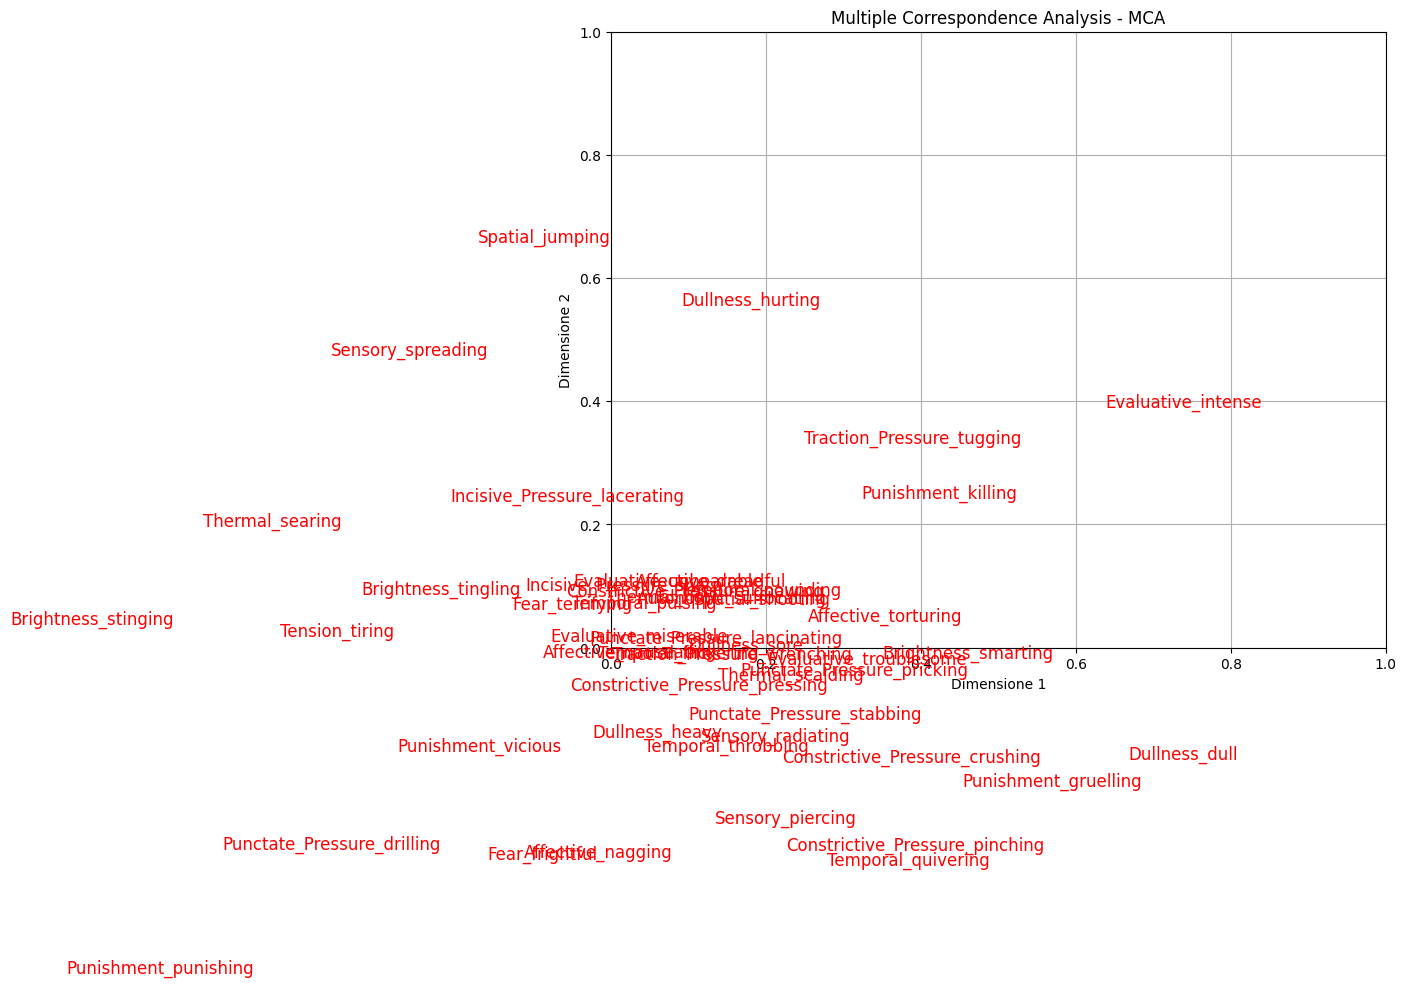

In [29]:
import prince
df_encoded = pd.get_dummies(df[[  'Temporal', 'Spatial',  'Punctate_Pressure',  'Incisive_Pressure',  'Constrictive_Pressure', 'Traction_Pressure',  'Thermal', 'Brightness',  'Dullness',   'Tension',  'Autonomic',  'Fear', 'Punishment',   'Evaluative',  'Sensory', 'Affective']], drop_first=True)  


mca = prince.MCA(n_components=15, engine='sklearn')
mca = mca.fit(df_encoded)
mca_coordinates = mca.transform(df_encoded)
print(mca_coordinates.head())
variables_coordinates = mca.column_coordinates(df_encoded)
plt.figure(figsize=(10, 8))
#plt.scatter(mca_coordinates[0], mca_coordinates[1], alpha=0.5, color='blue')
plt.title('Multiple Correspondence Analysis - MCA')
plt.xlabel('Dimensione 1')
plt.ylabel('Dimensione 2')
for i in range(min(variables_coordinates.shape[0], df_encoded.shape[1])):
    plt.text(variables_coordinates.iloc[i, 0], variables_coordinates.iloc[i, 1], 
             df_encoded.columns[i], color='red', fontsize=12)
plt.grid(True)
plt.show()

In [30]:
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.040,3.97%,3.97%
1,0.039,3.92%,7.88%
2,0.038,3.82%,11.71%
3,0.037,3.72%,15.43%
4,0.037,3.65%,19.09%
5,0.036,3.62%,22.70%
6,0.033,3.32%,26.02%
7,0.033,3.31%,29.33%
8,0.032,3.24%,32.57%


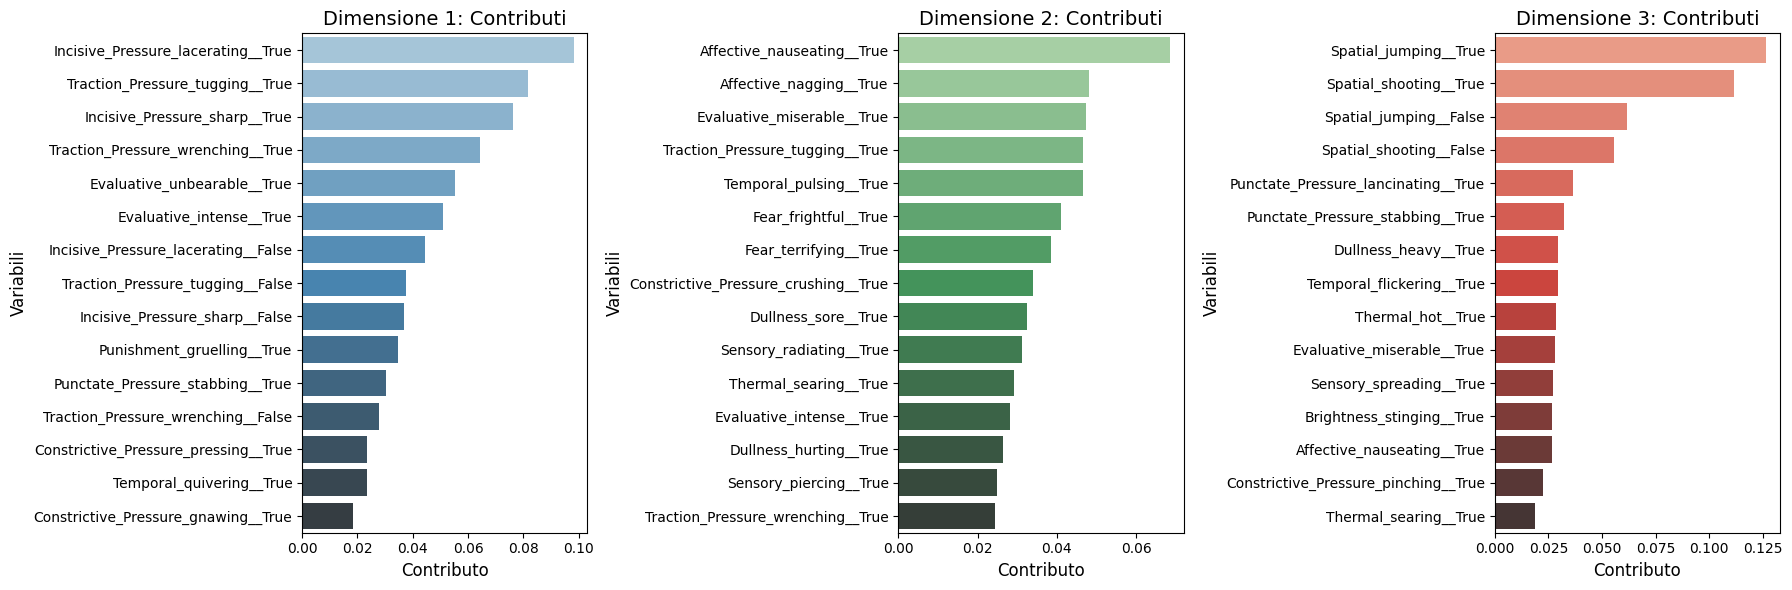

In [31]:
contributions = mca.column_contributions_

top_contributions = contributions.iloc[:, :3]

top_contributions_1 = top_contributions.iloc[:, 0].sort_values(ascending=False).head(15)
top_contributions_2 = top_contributions.iloc[:, 1].sort_values(ascending=False).head(15)
top_contributions_3 = top_contributions.iloc[:, 2].sort_values(ascending=False).head(15)

top_contributions_1 = contributions.iloc[:, 0].sort_values(ascending=False).head(15)
top_contributions_2 = contributions.iloc[:, 1].sort_values(ascending=False).head(15)
top_contributions_3 = contributions.iloc[:, 2].sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x=top_contributions_1.values, y=top_contributions_1.index, ax=axes[0], palette='Blues_d')
axes[0].set_title('Dimensione 1: Contributi', fontsize=14)
axes[0].set_xlabel('Contributo', fontsize=12)
axes[0].set_ylabel('Variabili', fontsize=12)

sns.barplot(x=top_contributions_2.values, y=top_contributions_2.index, ax=axes[1], palette='Greens_d')
axes[1].set_title('Dimensione 2: Contributi', fontsize=14)
axes[1].set_xlabel('Contributo', fontsize=12)
axes[1].set_ylabel('Variabili', fontsize=12)

sns.barplot(x=top_contributions_3.values, y=top_contributions_3.index, ax=axes[2], palette='Reds_d')
axes[2].set_title('Dimensione 3: Contributi', fontsize=14)
axes[2].set_xlabel('Contributo', fontsize=12)
axes[2].set_ylabel('Variabili', fontsize=12)

plt.tight_layout()
plt.show()

# Scoring 2, totale delle sezioni

In [32]:
var_factor=['liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
       'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
       'sleep', 'lying_down', 'distraction', 'urination', 'tension',
       'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
       'fatigue']
for col in df.columns:
    if col in var_factor:
        df[f'{col}'] = df[col].apply(lambda x: 1 if x == 'increase' else 0)

In [33]:
var=[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Pain_Least_Score', 'Worst_Toothache_Score', 'Worst_Headache_Score', 'Worst_Stomachache_Score', 'liquor',
 'stimulants',
 'eating',
 'heat',
 'cold',
 'damp',
 'weather_changes',
 'massage',
 'pressure',
 'no_movement',
 'movement',
 'sleep',
 'lying_down',
 'distraction',
 'urination',
 'tension',
 'bright_lights',
 'loud_noises',
 'work',
 'intercourse',
 'mild_exercise',
 'fatigue']
df['Total Pain Score'] = df[var].sum(axis=1)

Il punteggio massimo raggiungibile da tutte le sezioni è 130, per cui si adotta il seguente scoring: 

- basso dolore se totale < 65 (50%)
- medio dolore se totale > 65 e minore di <91
- dolore alto se totale > 91


In [34]:
df['scoring_2'] = df['Total Pain Score'].apply(lambda x: 'Basso Dolore' if x < 65 else ('Medio Dolore' if x < 90 else 'Alto Dolore'))
df['scoring_2'] = df['scoring_2'].astype('category')


In [35]:
df['scoring_2'].value_counts()

scoring_2
Basso Dolore    191
Alto Dolore     181
Medio Dolore    126
Name: count, dtype: int64

In [36]:
df['scoring_2_num'] = df['Total Pain Score'].apply(lambda x: 1 if x < 65 else (2 if x < 91 else 3))
df['scoring_2_num'] = df['scoring_2_num'].astype('category')

In [37]:
table_sex = pd.crosstab(df['scoring_2_num'], df['Sex'], margins=True)
table_sex_percent = table_sex.div(table_sex.loc['All'], axis=1) * 100  # Percentuali per colonna

age_stats = df.groupby('scoring_2_num')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
age_stats['IQR'] = df.groupby('scoring_2_num')['Age'].quantile(0.75) - df.groupby('scoring_2_num')['Age'].quantile(0.25)

chi2, p, dof, expected = stats.chi2_contingency(table_sex.iloc[:-1, :-1])  # Rimuoviamo la riga 'All' per il test

group1 = df[df['scoring_2_num'] == 1]['Age']
group2 = df[df['scoring_2_num'] == 2]['Age']
group3 = df[df['scoring_2_num'] == 3]['Age']
t_stat_12, p_value_12 = stats.ttest_ind(group1, group2, equal_var=False)
t_stat_13, p_value_13 = stats.ttest_ind(group1, group3, equal_var=False)
t_stat_23, p_value_23 = stats.ttest_ind(group2, group3, equal_var=False)

summary_table = pd.DataFrame({
    'Scoring Group': [1, 2, 3],
    'N (Totale)': age_stats['count'].values,
    'Età Media (SD)': [f"{m:.1f} ({s:.1f})" for m, s in zip(age_stats['mean'], age_stats['std'])],
    'Mediana (IQR)': [f"{med:.1f} ({iqr:.1f})" for med, iqr in zip(age_stats['median'], age_stats['IQR'])],
    'Maschi (%)': [f"{table_sex_percent.loc[i, 'M']:.1f}%" for i in range(1, 4)],
    'Femmine (%)': [f"{table_sex_percent.loc[i, 'F']:.1f}%" for i in range(1, 4)]
})

print(summary_table.to_string(index=False))
print(f"Chi-quadro per il sesso tra i gruppi: χ² = {chi2:.2f}, p-value = {p:.3f}")
print(f"T-test età tra 1 e 2: t = {t_stat_12:.2f}, p-value = {p_value_12:.3f}")
print(f"T-test età tra 1 e 3: t = {t_stat_13:.2f}, p-value = {p_value_13:.3f}")
print(f"T-test età tra 2 e 3: t = {t_stat_23:.2f}, p-value = {p_value_23:.3f}")

 Scoring Group  N (Totale) Età Media (SD) Mediana (IQR) Maschi (%) Femmine (%)
             1         191    47.4 (17.6)   46.0 (29.0)      36.2%       40.8%
             2         129    50.9 (18.1)   50.0 (29.0)      29.2%       22.3%
             3         178    49.2 (17.7)   49.0 (28.0)      34.6%       37.0%
Chi-quadro per il sesso tra i gruppi: χ² = 3.20, p-value = 0.201
T-test età tra 1 e 2: t = -1.72, p-value = 0.087
T-test età tra 1 e 3: t = -0.97, p-value = 0.331
T-test età tra 2 e 3: t = 0.83, p-value = 0.408


/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_15742/3145740463.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats = df.groupby('scoring_2_num')['Age'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
/var/folders/v4/mmjnlvt146z3mggjxb3zm4b40000gn/T/ipykernel_15742/3145740463.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats['IQR'] = df.groupby('scoring_2_num')['Age'].quantile(0.75) - df.groupby('scoring_2_num')['Age'].quantile(0.25)


In [38]:
model_dir = "scoring_2 - model , medicinegpt"
os.makedirs(model_dir, exist_ok=True)

X = df[[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Pain_Least_Score', 'Worst_Toothache_Score', 'Worst_Headache_Score', 'Worst_Stomachache_Score', 'liquor',
 'stimulants',
 'eating',
 'heat',
 'cold',
 'damp',
 'weather_changes',
 'massage',
 'pressure',
 'no_movement',
 'movement',
 'sleep',
 'lying_down',
 'distraction',
 'urination',
 'tension',
 'bright_lights',
 'loud_noises',
 'work',
 'intercourse',
 'mild_exercise',
 'fatigue']]

y = df['scoring_2_num'] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  # Salta righe che non contengono numeri validi

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")



Performing Stepwise Regression for SVM...


/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Variabili selezionate per SVM: ['Temporal_Score', 'Spatial_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Fear_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Worst_Toothache_Score', 'Worst_Headache_Score', 'Worst_Stomachache_Score', 'pressure', 'no_movement', 'movement', 'lying_down', 'distraction', 'urination', 'bright_lights', 'mild_exercise']
Modelli per SVM salvati in scoring_2 - model , medicinegpt/SVM_all_features.pkl e scoring_2 - model , medicinegpt/SVM_selected_features.pkl
Accuracy (All features): 0.97
Accuracy (Stepwise features): 0.95
Classification Report (All features):
               precision    recall  f1-score   support

           1       0.97      1.00      0.99        38
           2       1.00      0.88      0.94        26
           3       0.95      1.00      0.97        36

    accuracy                           0.97       100
  

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/Users/stefanocirillo/anaconda3/lib/python3.12/site-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got [1 2 3]


# Scoring 3


In [39]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder
from statsmodels.multivariate.manova import MANOVA
from sklearn.metrics import cohen_kappa_score
from sklearn.utils.extmath import cartesian
from factor_analyzer import FactorAnalyzer
from pingouin import cronbach_alpha

In [40]:
dataset_path = f"../dataset/McGill_Pain_Questionnaire_DOCTORAI.csv"
df = pd.read_csv(dataset_path)
df

,ID,Sex,Age,BPM,Temporal,Temporal_Score,Spatial,Spatial_Score,Punctate_Pressure,Punctate_Pressure_Score,...,Work,surgery_site,tumor_sitology,irradiation_site,osteoarthropathy,pain_projection,pain_type,Total_Pain_Score,Tipo_dolore,PRI
0,1,M,19,107,beating,1,flashing,1,pricking,1,...,8.0,Lobectomy scar,Central lung mass,NaN,NaN,Radiates along C7-T1,neuropathic,20,acute,20
1,2,F,71,109,pounding,1,shooting,1,lancinating,1,...,1.0,Post-thoracotomy incision site,Apex of the right lung,Radiation therapy right lung,Pain in elbows and knees,Radiates along C7-T1,neuropathic,20,acute,20
2,3,F,70,64,flickering,2,jumping,2,boring,1,...,8.0,Lobectomy scar,Apex of the right lung,Radiation therapy left lung,Wrist osteoarthropathy,Radiates along C7-T1,neuropathic,27,acute,27
3,4,M,59,94,quivering,1,jumping,1,drilling,1,...,6.0,Lobectomy scar,Central lung mass,Radiation therapy left lung,Wrist osteoarthropathy,Localized with no transmission,nociceptive,20,acute,20
4,5,M,60,112,pulsing,2,jumping,1,pricking,1,...,7.0,Lobectomy scar,Apex of the right lung,NaN,Pain in elbows and knees,Radiates along C7-T1,neuropathic,27,acute,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,494,F,66,120,throbbing,4,jumping,3,pricking,4,...,4.0,Post-thoracotomy incision site,Apex of the right lung,NaN,Pain in elbows and knees,Radiates along C7-T1,neuropathic,73,chronic,73
494,495,F,71,84,beating,4,jumping,4,drilling,4,...,5.0,Post-thoracotomy incision site,Apex of the right lung,Radiation therapy left lung,Wrist osteoarthropathy,Localized with no transmission,neuropathic,75,chronic,75
495,496,M,58,64,pounding,3,flashing,3,drilling,4,...,5.0,Post-thoracotomy incision site,Central lung mass,Radiation therapy right lung,Pain in elbows and knees,Radiates along C7-T1,neuropathic,66,chronic,66
496,497,F,74,101,pulsing,3,jumping,4,drilling,4,...,7.0,Post-thoracotomy incision site,Central lung mass,NaN,Wrist osteoarthropathy,Radiates along C7-T1,neuropathic,67,chronic,67


In [ ]:
var_factor=['liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
       'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
       'sleep', 'lying_down', 'distraction', 'urination', 'tension',
       'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
       'fatigue']

for col in df.columns:
    if col in var_factor:
        df[f'{col}'] = df[col].apply(lambda x: 1 if x == 'increase' else 0)
        
        desired_scores = ['Temporal_Score', 'Spatial_Score', 
           'Punctate_Pressure_Score', 
           'Incisive_Pressure_Score', 
           'Constrictive_Pressure_Score', 
           'Traction_Pressure_Score',  'Thermal_Score', 
           'Brightness_Score',  'Dullness_Score', 
           'Sensory_Misc_Score', 'Tension_Score',
           'Autonomic_Score',  'Fear_Score', 
           'Punishment_Score', 
           'Affective_Eval_Sensory_Score', 'Evaluative_Score',
           'Sensory_Score',  'Sensory2_Score', 
           'Sensory3_Score',  'Affective_Score', 'Pain_Now_Score', 
           'Pain_Worst_Score',  'Pain_Least_Score', 
           'Worst_Toothache_Score',  'Worst_Headache_Score',
           'Worst_Stomachache_Score', 'liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
           'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
           'sleep', 'lying_down', 'distraction', 'urination', 'tension',
           'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
           'fatigue']
        
df['Total Pain Score'] = df[desired_scores].sum(axis=1)
def discretizza_punteggio(punteggi, d):
    return [round((p / d) * 10) for p in punteggi]

df['scoring_3']=discretizza_punteggio(df['PRI'], 78)
df['scoring_4']=discretizza_punteggio(df['Total Pain Score'], 130)

In [ ]:
data_sel=df[['scoring_3','scoring_4', 'Sex', 'Activity', 'Enjoy',
       'Mood', 'Relate', 'Sleep', 'Walk', 'Work']]

In [41]:
def classify_pain(value, model):
    if model == 'CP36':
        return 'Mild' if value <= 3 else 'Moderate' if value <= 6 else 'Severe'
    elif model == 'CP37':
        return 'Mild' if value <= 3 else 'Moderate' if value <= 7 else 'Severe'
    elif model == 'CP46':
        return 'Mild' if value <= 4 else 'Moderate' if value <= 6 else 'Severe'
    elif model == 'CP47':
        return 'Mild' if value <= 4 else 'Moderate' if value <= 7 else 'Severe'
    else:
        return None

data_models = {}
for model in ['CP36', 'CP37', 'CP46', 'CP47']:
    data_copy = data_sel.copy()
    data_copy['Pain_Level'] = data_copy['scoring_4'].apply(lambda x: classify_pain(x, model))
    data_models[model] = data_copy

manova_results = {}
for model, df in data_models.items():
    maov = MANOVA.from_formula('Activity + Enjoy + Mood + Relate+ Sleep + Walk + Work ~ Pain_Level+Sex', df)
    manova_results[model] = maov.mv_test()

for model, result in manova_results.items():
    print(f"\n### MANOVA Results for {model} ###")
    print(result)

cronbach_results = {}
for model, df in data_models.items():
    items = df[['Activity', 'Enjoy',
       'Mood', 'Relate', 'Sleep', 'Walk', 'Work']]
    items = items.apply(pd.to_numeric, errors='coerce')
    alpha, _ = cronbach_alpha(items)
    cronbach_results[model] = alpha
    print(f"\nCronbach's Alpha for {model}: {alpha:.4f}")

best_model = max(cronbach_results, key=cronbach_results.get)
print(f"\nIl miglior modello di cut-off è: {best_model} con Alpha = {cronbach_results[best_model]:.4f}")


### MANOVA Results for CP36 ###
                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.2941 7.0000 488.0000 167.3669 0.0000
         Pillai's trace 0.7059 7.0000 488.0000 167.3669 0.0000
 Hotelling-Lawley trace 2.4008 7.0000 488.0000 167.3669 0.0000
    Roy's greatest root 2.4008 7.0000 488.0000 167.3669 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
       Pain_Level       Value   Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.9791 14.0000 976.0000  0.7406 0.7341
         Pillai's trace 0.0210 14.0000 97

In [42]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder

cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: mild, 1: moderate, 2: severe
    return np.nan

def analyze_cutoffs(data, cutoffs):
    data = data_sel.copy()
    data["Pain_Category"] = data["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    formula = "Activity + Enjoy + Mood + Relate+ Sleep + Walk + Work ~ Pain_Category + Sex"
    maov = MANOVA.from_formula(formula, data)
    return maov.mv_test()    

data = data_sel.copy()
results = {}
for model, cutoffs in cut_off_models.items():
    results[model] = analyze_cutoffs(data, cutoffs)

for model, res in results.items():
    print(f"Results for {model}:")
    print(res)
    print("\n" + "-"*50 + "\n")

Results for CP37:
                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0678 7.0000 489.0000 959.8967 0.0000
         Pillai's trace  0.9322 7.0000 489.0000 959.8967 0.0000
 Hotelling-Lawley trace 13.7409 7.0000 489.0000 959.8967 0.0000
    Roy's greatest root 13.7409 7.0000 489.0000 959.8967 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
            Sex           Value  Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
            Wilks' lambda 0.9870 7.0000 489.0000  0.9174 0.4925
           Pillai's trace 0.0130 7.0000 4

In [43]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# I modelli di cut-off testati:
# CP37: [1-3] lieve, [4-7] moderato, [8-10] severo
# CP36: [1-3] lieve, [4-6] moderato, [7-10] severo
# CP47: [1-4] lieve, [5-7] moderato, [8-10] severo
# CP46: [1-4] lieve, [5-6] moderato, [7-10] severo
cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: lieve, 1: moderato, 2: severo
    return np.nan

def analyze_cutoffs(data, cutoffs):
    data=data_sel.copy()
    data["Pain_Category"] = data["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    formula = "Activity + Enjoy + Mood + Relate+ Sleep + Walk + Work ~ C(Pain_Category) * C(Sex)"
    maov = MANOVA.from_formula(formula, data)
    result = maov.mv_test()
    return result
def compute_partial_eta_squared(data, dependent_var):
    model = ols(f"{dependent_var} ~ C(Pain_Category)", data=data).fit()
    anova_results = anova_lm(model, typ=2)
    ss_effect = anova_results.loc["C(Pain_Category)", "sum_sq"]
    ss_error = anova_results.loc["Residual", "sum_sq"]
    partial_eta_sq = ss_effect / (ss_effect + ss_error)
    return partial_eta_sq

interference_vars = ["Activity","Enjoy",  "Mood", "Sleep", "Work", "Relate", "Walk"]

model_results = {}
for model, cutoffs in cut_off_models.items():
    print(f"Analisi per il modello {model}:")
    
    res = analyze_cutoffs(data.copy(), cutoffs)
    stat_table = res.results['C(Pain_Category)']['stat']
    f_val = stat_table.loc[stat_table.index[0], "F Value"]
    print("Valore F (MANOVA):", f_val)
    
    data_model = data.copy()
    data_model["Pain_Category"] = data_model["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    eta2_values = {}
    for var in interference_vars:
        eta2_values[var] = compute_partial_eta_squared(data_model, var)
    avg_eta2 = np.mean(list(eta2_values.values()))
    print("Partial Eta Squared per variabile:", eta2_values)
    print("Media Partial Eta Squared:", avg_eta2)
    print("-" * 50)
    
    model_results[model] = {"F_value": f_val, "avg_eta2": avg_eta2, "eta2_values": eta2_values}

best_model_by_F = max(model_results, key=lambda m: model_results[m]["F_value"])
best_model_by_eta2 = max(model_results, key=lambda m: model_results[m]["avg_eta2"])

print("Modello migliore in base al Valore F (MANOVA):", best_model_by_F,
      "con F =", model_results[best_model_by_F]["F_value"])
print("Modello migliore in base al Partial Eta Squared medio:", best_model_by_eta2,
      "con Partial Eta Squared =", model_results[best_model_by_eta2]["avg_eta2"])


# Per una valutazione quantitativa, potresti estrarre i valori F per:
# 1) L'effetto principale di C(Pain_Category)
# 2) L'interazione C(Pain_Category):C(Sex)
#
# Se l'F dell'interazione è basso rispetto a quello dell'effetto principale,
# questo suggerisce che la classificazione è robusta rispetto al sesso.
best_model = "CP47"
best_cutoffs = cut_off_models[best_model]
res_cp47 = analyze_cutoffs(data.copy(), best_cutoffs)

stat_table_main = res_cp47.results['C(Pain_Category)']['stat']
stat_table_inter = res_cp47.results['C(Pain_Category):C(Sex)']['stat']

F_main_cp47 = stat_table_main.loc[stat_table_main.index[0], "F Value"]
F_inter_cp47 = stat_table_inter.loc[stat_table_inter.index[0], "F Value"]

print("Modello CP47 - Valore F per l'effetto principale (C(Pain_Category)):", F_main_cp47)
print("Modello CP47 - Valore F per l'interazione (C(Pain_Category):C(Sex)):", F_inter_cp47)

# Se F_inter_cp47 è molto inferiore a F_main_cp47, allora la classificazione (basata su Pain_Worst) è robusta rispetto al sesso.
if F_inter_cp47 < F_main_cp47:
    print("\nL'interazione con il sesso è bassa, indicando che la classificazione è robusta rispetto al sesso.")
else:
    print("\nL'interazione con il sesso è alta; potrebbe esserci una differenza nell'effetto della classificazione tra maschi e femmine.")

Analisi per il modello CP37:
Valore F (MANOVA): 0.812579928672729
Partial Eta Squared per variabile: {'Activity': 0.0011341017368272314, 'Enjoy': 0.005243316161331848, 'Mood': 0.006939830767765124, 'Sleep': 0.0074919902046433, 'Work': 0.007191868359545795, 'Relate': 0.0024304436956394315, 'Walk': 0.0062003493246047875}
Media Partial Eta Squared: 0.0052331286071939315
--------------------------------------------------
Analisi per il modello CP36:
Valore F (MANOVA): 0.4878130265466825
Partial Eta Squared per variabile: {'Activity': 0.005288281160290291, 'Enjoy': 0.003371491511171582, 'Mood': 0.007398885005551426, 'Sleep': 0.004061252460092045, 'Work': 0.006132976475020913, 'Relate': 0.003040223977425773, 'Walk': 0.002626640258331479}
Media Partial Eta Squared: 0.004559964406840501
--------------------------------------------------
Analisi per il modello CP47:
Valore F (MANOVA): 0.7337927067274065
Partial Eta Squared per variabile: {'Activity': 0.00044982845621732834, 'Enjoy': 0.005093372

In [44]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA

# 1) Definisco i modelli di cut-off
cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

# 2) Funzione per assegnare la categoria di dolore
def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: lieve, 1: moderato, 2: severo
    return np.nan

# 3) Funzione che esegue la MANOVA e ricava i valori F
#    - F per l'effetto principale: 'C(Pain_Level)'
#    - F per l'interazione: 'C(Pain_Level):C(Nation)'
#    - Estratti per i test: Pillai, Hotelling, Wilks
def get_f_values_for_model(data, cutoffs):
    df = data.copy()    
    df["Pain_Level"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))    
    formula = "Activity + Enjoy + Mood + Relate+ Sleep + Walk + Work ~ C(Pain_Level) * C(Sex)"
    maov = MANOVA.from_formula(formula, df)
    mv_res = maov.mv_test()
    
    # Ricava le tabelle per l'effetto principale e per l'interazione
    main_stat = mv_res.results["C(Pain_Level)"]["stat"]
    inter_stat = mv_res.results["C(Pain_Level):C(Sex)"]["stat"]
    
    tests = ["Pillai's trace", "Hotelling-Lawley trace", "Wilks' lambda"]
    

    # main_F = F dell’effetto principale, inter_F = F dell’interazione
    # ratio = main_F / inter_F
    out = {}
    for test_name in tests:
        main_F = main_stat.loc[test_name, "F Value"]
        inter_F = inter_stat.loc[test_name, "F Value"]
        ratio = main_F / inter_F if inter_F != 0 else np.nan
        out[test_name] = (inter_F, main_F, ratio)
    return out

# 4) Ciclo sui modelli di cut-off 
results_all = {}
for model_name, cutoffs in cut_off_models.items():
    fvals = get_f_values_for_model(data, cutoffs)
    results_all[model_name] = fvals

# 5) Tabella per modello 

rows = [
    ("Pillai's trace", "F(Pain by Sex)"),
    ("Pillai's trace", "F(Pain Level)"),
    ("Pillai's trace", "Ratio"),
    ("Hotelling-Lawley trace", "F(Pain by Sex)"),
    ("Hotelling-Lawley trace", "F(Pain Level)"),
    ("Hotelling-Lawley trace", "Ratio"),
    ("Wilks' lambda", "F(Pain by Sex)"),
    ("Wilks' lambda", "F(Pain Level)"),
    ("Wilks' lambda", "Ratio"),
]


table_data = []
for row in rows:
    test_name, label = row
    row_dict = {"Test": f"{test_name} {label}"}
    for model_name in cut_off_models.keys():
        # results_all[model_name][test_name] = (inter_F, main_F, ratio)
        interF, mainF, ratio = results_all[model_name][test_name]
        if "Sex" in label:  # F(Pain by Nation) = inter_F
            val = interF
        elif "Pain Level" in label:  # F(Pain Level) = main_F
            val = mainF
        else:  # Ratio
            val = ratio
        row_dict[model_name] = val
    table_data.append(row_dict)

df_table = pd.DataFrame(table_data)
print("\n--- Tabella stile paper ---")
print(df_table)

print("\n--- Tabella in formato LaTeX ---")
print(df_table.to_latex(index=False, float_format="%.2f"))



--- Tabella stile paper ---
                                    Test      CP37      CP36      CP47  \
0          Pillai's trace F(Pain by Sex)  1.302538  1.267728  1.286926   
1           Pillai's trace F(Pain Level)  0.814151  0.487598  0.735036   
2                   Pillai's trace Ratio  0.625050  0.384623  0.571156   
3  Hotelling-Lawley trace F(Pain by Sex)  1.302923  1.268178  1.287715   
4   Hotelling-Lawley trace F(Pain Level)  0.811432  0.488278  0.732932   
5           Hotelling-Lawley trace Ratio  0.622778  0.385024  0.569172   
6           Wilks' lambda F(Pain by Sex)  1.302395  1.267627  1.286989   
7            Wilks' lambda F(Pain Level)  0.812580  0.487813  0.733793   
8                    Wilks' lambda Ratio  0.623912  0.384824  0.570162   

       CP46  
0  1.174667  
1  0.392261  
2  0.333933  
3  1.177619  
4  0.392103  
5  0.332963  
6  1.175843  
7  0.392081  
8  0.333447  

--- Tabella in formato LaTeX ---
\begin{tabular}{lrrrr}
\toprule
Test & CP37 & CP36 & CP4

In [45]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# -------- 1) Definizione dei cut-off e funzioni preesistenti --------

cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0: lieve, 1: moderato, 2: severo
    return np.nan

def analyze_cutoffs(data, cutoffs):
    data = data.copy()
    data["Pain_Category"] = data["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    formula = "Activity + Enjoy + Mood + Relate + Sleep + Walk + Work ~ C(Pain_Category) * C(Sex)"
    maov = MANOVA.from_formula(formula, data)
    return maov.mv_test()

def compute_partial_eta_squared(data, dependent_var):
    model = ols(f"{dependent_var} ~ C(Pain_Category)", data=data).fit()
    anova_results = anova_lm(model, typ=2)
    ss_effect = anova_results.loc["C(Pain_Category)", "sum_sq"]
    ss_error = anova_results.loc["Residual", "sum_sq"]
    partial_eta_sq = ss_effect / (ss_effect + ss_error)
    return partial_eta_sq

# Funzioni per Cronbach's alpha
def cronbach_alpha(df_items):
    items = df_items.to_numpy(dtype=float)
    k = items.shape[1]
    var_items = items.var(axis=0, ddof=1)
    total_score = items.sum(axis=1)
    var_total = total_score.var(ddof=1)
    alpha = (k / (k - 1)) * (1 - var_items.sum() / var_total)
    return alpha

def alpha_if_item_deleted(df_items):
    results = {}
    for col in df_items.columns:
        alpha_del = cronbach_alpha(df_items.drop(columns=[col]))
        results[col] = alpha_del
    return results

# -------- 2) Analisi dei modelli e selezione  --------

interference_vars = ["Activity","Enjoy","Mood","Sleep","Work","Relate","Walk"]

def run_analysis(data):
    model_results = {}
    for model, cutoffs in cut_off_models.items():
        print(f"Analisi per il modello {model}:")
        
        # MANOVA: calcola il valore F (Pillai's trace)
        res = analyze_cutoffs(data, cutoffs)
        stat_table = res.results['C(Pain_Category)']['stat']
        f_val = stat_table.loc[stat_table.index[0], "F Value"]
        print("Valore F (MANOVA):", f_val)
        
        # Partial Eta Squared medio
        data_model = data.copy()
        data_model["Pain_Category"] = data_model["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
        eta2_values = {}
        for var in interference_vars:
            eta2_values[var] = compute_partial_eta_squared(data_model, var)
        avg_eta2 = np.mean(list(eta2_values.values()))
        
        print("Partial Eta Squared per variabile:", eta2_values)
        print("Media Partial Eta Squared:", avg_eta2)
        print("-" * 50)
        
        model_results[model] = {"F_value": f_val, "avg_eta2": avg_eta2, "eta2_values": eta2_values}
    
    best_model_by_F = max(model_results, key=lambda m: model_results[m]["F_value"])
    best_model_by_eta2 = max(model_results, key=lambda m: model_results[m]["avg_eta2"])
    
    print("Modello migliore in base al Valore F (MANOVA):", best_model_by_F,
          "con F =", model_results[best_model_by_F]["F_value"])
    print("Modello migliore in base al Partial Eta Squared medio:", best_model_by_eta2,
          "con Partial Eta Squared =", model_results[best_model_by_eta2]["avg_eta2"])
    
    return best_model_by_F, best_model_by_eta2, model_results

# -------- 3) Calcolo di Cronbach's alpha a ciascun livello (lieve, moderato, severo) --------

def cronbach_table_for_model(data, cutoffs):
    """
    Per ciascun livello di dolore (0=lieve, 1=moderato, 2=severo), 
    calcola:
    - Cronbach's alpha complessivo sulle 7 interferenze
    - Alpha if item deleted per ciascun item
    Ritorna un dizionario con i risultati.
    """
    df = data.copy()
    df["Pain_Category"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    
    results_by_level = {}
    for level in [0, 1, 2]:
        subset = df[df["Pain_Category"] == level]
        if len(subset) == 0:
            continue        
        df_items = subset[interference_vars].dropna()        
        alpha_full = cronbach_alpha(df_items)
        alpha_deleted = alpha_if_item_deleted(df_items)
        
        results_by_level[level] = {
            "N": len(df_items),
            "alpha_full": alpha_full,
            "alpha_deleted": alpha_deleted
        }
    return results_by_level



# 4.1) Esegue l'analisi e individua il modello migliore
best_model_F, best_model_eta, all_results = run_analysis(data)

# 4.2) Cronbach's alpha per CP47
best_model = "CP37"
best_cutoffs = cut_off_models[best_model]
alpha_results = cronbach_table_for_model(data, best_cutoffs)

# 4.3) 
print("\n=== Cronbach's Alpha per CP37 (suddivisione: 1-4 lieve, 5-7 moderato, 8-10 severo) ===")
for level in alpha_results:
    level_name = {0: "Mild (1-4)", 1: "Moderate (5-7)", 2: "Severe (8-10)"}[level]
    info = alpha_results[level]
    print(f"\n*** {level_name} pain level ***")
    print("N =", info["N"])
    print("Interference alpha =", round(info["alpha_full"], 4))
    
    # Alpha if item deleted
    print("Alpha if item deleted:")
    for item, alpha_val in info["alpha_deleted"].items():
        print(f"  {item}: {round(alpha_val, 4)}")



Analisi per il modello CP37:
Valore F (MANOVA): 0.812579928672729
Partial Eta Squared per variabile: {'Activity': 0.0011341017368272314, 'Enjoy': 0.005243316161331848, 'Mood': 0.006939830767765124, 'Sleep': 0.0074919902046433, 'Work': 0.007191868359545795, 'Relate': 0.0024304436956394315, 'Walk': 0.0062003493246047875}
Media Partial Eta Squared: 0.0052331286071939315
--------------------------------------------------
Analisi per il modello CP36:
Valore F (MANOVA): 0.4878130265466825
Partial Eta Squared per variabile: {'Activity': 0.005288281160290291, 'Enjoy': 0.003371491511171582, 'Mood': 0.007398885005551426, 'Sleep': 0.004061252460092045, 'Work': 0.006132976475020913, 'Relate': 0.003040223977425773, 'Walk': 0.002626640258331479}
Media Partial Eta Squared: 0.004559964406840501
--------------------------------------------------
Analisi per il modello CP47:
Valore F (MANOVA): 0.7337927067274065
Partial Eta Squared per variabile: {'Activity': 0.00044982845621732834, 'Enjoy': 0.005093372

In [46]:

from statsmodels.multivariate.manova import MANOVA
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
### ANCHE PER SESSO OLTRE CHE PER PAIN
# --- Cut-off e funzioni di base  ---
cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}

def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0 = lieve, 1 = moderato, 2 = severo
    return np.nan

def cronbach_alpha(df_items):
    """ Calcola l'alpha di Cronbach su un set di item (colonne). """
    items = df_items.to_numpy(dtype=float)
    k = items.shape[1]
    var_items = items.var(axis=0, ddof=1)
    total_score = items.sum(axis=1)
    var_total = total_score.var(ddof=1)
    alpha = (k / (k - 1)) * (1 - var_items.sum() / var_total)
    return alpha

def alpha_if_item_deleted(df_items):
    """
    Restituisce un dizionario {nome_item: alpha_senza_item} 
    calcolando alpha di Cronbach escludendo ogni item a turno.
    """
    results = {}
    for col in df_items.columns:
        df_temp = df_items.drop(columns=[col])
        results[col] = cronbach_alpha(df_temp)
    return results

# --- Variabili di interferenza ---
interference_vars = ["Activity","Enjoy","Mood","Sleep","Work","Relate","Walk"]

# --- Funzione per calcolare Cronbach's alpha per (Pain Category, Sex) ---
def cronbach_table_for_model_by_sex(data, cutoffs):
    """
    Per ciascuna combinazione di Pain_Category (0,1,2) e Sex (ad es. M,F),
    calcola:
      - N (numero di osservazioni)
      - alpha_full (cronbach alpha su tutti gli item)
      - alpha_if_item_deleted (cronbach alpha escludendo ogni item)
    Ritorna un dizionario annidato:
      results[sex][pain_category] = { 'N': ..., 'alpha_full': ..., 'alpha_deleted': {...} }
    """
    df = data.copy()
    df["Pain_Category"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))
    
    sexes = df["Sex"].dropna().unique()  
    
    results = {}
    for s in sexes:
        results[s] = {}
        for level in [0, 1, 2]:
            subset = df[(df["Pain_Category"] == level) & (df["Sex"] == s)]
            if len(subset) == 0:
                continue            
            df_items = subset[interference_vars].dropna()
            
            alpha_full = cronbach_alpha(df_items)
            alpha_del = alpha_if_item_deleted(df_items)
            
            results[s][level] = {
                "N": len(df_items),
                "alpha_full": alpha_full,
                "alpha_deleted": alpha_del
            }
    
    return results

def main():
    best_model = "CP37"
    best_cutoffs = cut_off_models[best_model]
    alpha_results_sex = cronbach_table_for_model_by_sex(data, best_cutoffs)
    print("\n=== Cronbach's Alpha per CP47 diviso per Sesso e Livello di Dolore ===")
    for s in alpha_results_sex:
        print(f"\n=== Sesso: {s} ===")
        for level in sorted(alpha_results_sex[s].keys()):
            # 0 = mild, 1 = moderate, 2 = severe
            level_name = {0: "Mild (1-4)", 1: "Moderate (5-7)", 2: "Severe (8-10)"}[level]
            info = alpha_results_sex[s][level]
            print(f"\n--- {level_name} ---")
            print("N =", info["N"])
            print("Interference alpha =", round(info["alpha_full"], 4))
            print("Alpha if item deleted:")
            for item, alpha_val in info["alpha_deleted"].items():
                print(f"  {item}: {round(alpha_val, 4)}")
main()


=== Cronbach's Alpha per CP47 diviso per Sesso e Livello di Dolore ===

=== Sesso: M ===

--- Mild (1-4) ---
N = 70
Interference alpha = -0.0403
Alpha if item deleted:
  Activity: -0.0276
  Enjoy: -0.0848
  Mood: -0.0613
  Sleep: 0.0704
  Work: 0.0027
  Relate: -0.0769
  Walk: -0.0797

--- Moderate (5-7) ---
N = 89
Interference alpha = -0.0953
Alpha if item deleted:
  Activity: -0.102
  Enjoy: -0.0466
  Mood: -0.1187
  Sleep: -0.0869
  Work: -0.1474
  Relate: -0.0977
  Walk: 0.0188

--- Severe (8-10) ---
N = 101
Interference alpha = -0.0894
Alpha if item deleted:
  Activity: -0.241
  Enjoy: -0.2058
  Mood: 0.0985
  Sleep: -0.1607
  Work: 0.0133
  Relate: -0.1722
  Walk: 0.0323

=== Sesso: F ===

--- Mild (1-4) ---
N = 74
Interference alpha = -0.3219
Alpha if item deleted:
  Activity: -0.316
  Enjoy: -0.4342
  Mood: -0.408
  Sleep: -0.3061
  Work: -0.11
  Relate: -0.3554
  Walk: -0.0171

--- Moderate (5-7) ---
N = 68
Interference alpha = 0.0791
Alpha if item deleted:
  Activity: -0.008

In [47]:
variables = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]


# for var in variables:
#     df[var + "_2"] = 10 - df[var]
# for var in variables:
#      df[var] = 10 - df[var]

In [48]:
df["Pain_Level"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cutoffs))

KeyError: 'Pain_Level'

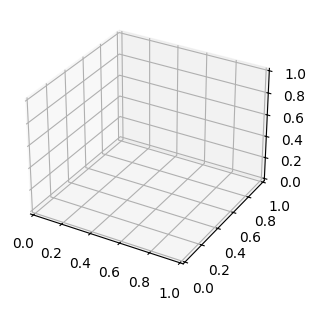

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  

def plot_3d_interference_by_sex(data, items, sex_col='Sex', pain_col='Pain_Level'):
    """
    Crea 7 subplot 3D (uno per ogni item in 'items') in cui:
      - Asse X = sesso (M, F)
      - Asse Y = livello di dolore (Mild, Moderate, Severe)
      - Asse Z = valore medio dell'item di interferenza (da 1 a 10).
    """
    pain_labels = ['Mild', 'Moderate','Severe' ]

    sexes = sorted(data[sex_col].dropna().unique())
    
#    print("Unique values in Sex column:", data[sex_col].unique())
#    print("Unique values in Pain_Level column:", data[pain_col].unique())    
    fig = plt.figure(figsize=(18, 12))
    
    for i, item in enumerate(items):
        ax = fig.add_subplot(3, 3, i + 1, projection='3d')
        
        group_means = data.groupby([sex_col, pain_col])[item].mean().reset_index()
#        print(group_means)
        
        dx = 0.4
        dy = 0.4
        base_value = 1 
        offset = 0.5  
        
        for s_i, sex_val in enumerate(sexes):
            for p_i, pain_level in enumerate(pain_labels):  
                
                subset = group_means[
                    (group_means[sex_col] == sex_val) & 
                    (group_means[pain_col] == pain_level)
                ]
                
                if len(subset) == 0:
                    mean_val = base_value  
                else:
                    mean_val = subset[item].values[0]
                
                x = s_i
                y = p_i
                color = 'blue' if sex_val == 'M' else 'red'
                
                dz = mean_val - base_value + offset
                
                if mean_val < base_value:
                    dz = offset  
                ax.bar3d(x, y, base_value, dx, dy, dz, color=color, alpha=0.8)
        
        ax.set_zlim(0, 10)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(sexes)
        ax.set_yticks(range(len(pain_labels)))
        ax.set_yticklabels(pain_labels)
        ax.set_xlabel('Sex')
        ax.set_ylabel('Pain Level')
        ax.set_zlabel('Mean Interference Value')
        ax.set_title(f'{item}')
    plt.tight_layout()
    plt.show()
    
items = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]
plot_3d_interference_by_sex(df, items, sex_col='Sex', pain_col='Pain_Level')

In [61]:
import pandas as pd

data = []

items = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]
pain_levels = ["Mild", "Moderate", "Severe"]

values = {
    "Activity": {
        "F": [5.07, 6.53, 8.58],
        "M": [4.52, 5.57, 8.04]
    },
    "Enjoy": {
        "F": [5.03, 6.08, 8.01],
        "M": [4.59, 5.51, 7.56]
    },
    "Mood": {
        "F": [4.56, 6.02, 8.09],
        "M": [4.01, 5.04, 7.58]
    },
    "Sleep": {
        "F": [5.08, 6.59, 8.52],
        "M": [4.54, 5.56, 8.07]
    },
    "Work": {
        "F": [5.57, 6.54, 8.02],
        "M": [5.06, 5.58, 7.53]
    },
    "Relate": {
        "F": [6.04, 7.06, 8.57],
        "M": [5.53, 6.01, 7.59]
    },
    "Walk": {
        "F": [5.02, 6.57, 8.53],
        "M": [4.58, 5.52, 8.06]
    }
}

# Costruzione dataframe in formato long
for item in items:
    for sex in ["F", "M"]:
        for i, pain in enumerate(pain_levels):
            data.append({
                "Sex": sex,
                "Pain_Level": pain,
                item: values[item][sex][i]
            })

# Converti in DataFrame wide (compatibile col tuo codice)
df = pd.DataFrame(data)

# Merge delle colonne per avere tutte le variabili
df = df.groupby(["Sex", "Pain_Level"]).first().reset_index()

Grafico salvato come: grouped_bar_1row_doctorai.pdf


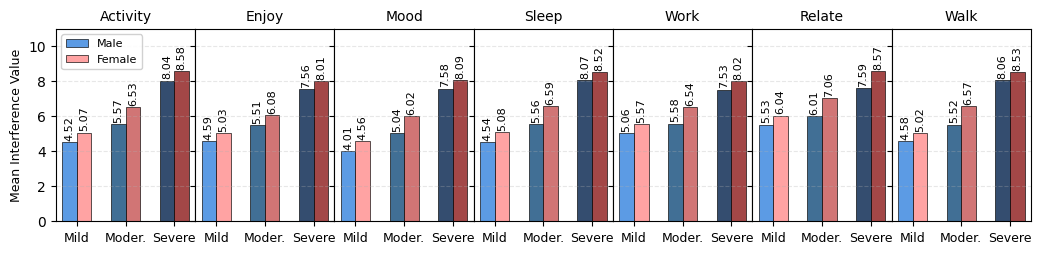

In [62]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grouped_bar_interference_by_sex(data, items, sex_col='Sex', pain_col='Pain_Level', 
                                         save_path='grouped_bar_plot.pdf'):
    pain_labels = ['Mild', 'Moderate', 'Severe']
    
    colors = {
        'M': {
            'Mild': '#4A90E2',
            'Moderate': '#2C5F8A',
            'Severe': '#1E3A5F'
        },
        'F': {
            'Mild': '#FF9999',
            'Moderate': '#CC6666',
            'Severe': '#993333'
        }
    }
    
    fig, axes = plt.subplots(1, 7, figsize=(13, 2.5), sharey=True)
    plt.subplots_adjust(wspace=0,hspace=0, left=0.05, right=0.8)
    
    if len(items) == 1:
        axes = [axes]
    
    # Barre più compatte
    total_width = 0.6
    bar_width = total_width / 2
    offset = bar_width / 2
    
    positions = {
        'M': -offset,
        'F': +offset
    }
    
    for idx, (ax, item) in enumerate(zip(axes, items)):
        group_means = data.groupby([sex_col, pain_col])[item].mean().reset_index()
        
        x = np.arange(len(pain_labels))
        
        means = {}
        for sex in ['M', 'F']:
            for pain in pain_labels:
                val = group_means[(group_means[sex_col] == sex) & 
                                 (group_means[pain_col] == pain)][item].values
                means[f'{sex}_{pain}'] = val[0] if len(val) > 0 else 0
        
        for i, pain in enumerate(pain_labels):
            for sex in ['M', 'F']:
                val = means[f'{sex}_{pain}']
                if val > 0:
                    x_pos = x[i] + positions[sex]
                    
                    ax.bar(x_pos, val, bar_width,
                           color=colors[sex][pain],
                           edgecolor='black', linewidth=0.5,
                           alpha=0.9,
                           label=('Male' if sex == 'M' else 'Female') if i == 0 else "")
                    
                    # Testo centrato sulla barra
                    ax.text(x_pos, val + 0.1,
                            f'{val:.2f}',
                            ha='center', va='bottom', fontsize=8, rotation=90)
        
        ax.set_xticks(x)
        ax.set_xticklabels(['Mild', 'Moder.', 'Severe'], fontsize=9)
        ax.set_ylim(0, 11)
        
        # Y label solo nel primo subplot
        if idx == 0:
            ax.set_ylabel('Mean Interference Value', fontsize=9)
        else:
            ax.set_ylabel('')
        
        ax.set_title(f'{item}', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')
        
        if idx == 0:
            ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    
    #fig.suptitle('Interference by Sex and Pain Level', fontsize=14, y=1.02, fontweight='bold')
    
    # Subplot più vicini
    plt.subplots_adjust(wspace=0)
    
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Grafico salvato come: {save_path}")
    
    plt.show()



# UTILIZZO
items = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]

plot_grouped_bar_interference_by_sex(df, items, sex_col='Sex', pain_col='Pain_Level', 
                                     save_path='grouped_bar_1row_doctorai.pdf')

In [ ]:

df = pd.read_csv(dataset_path)

desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score'
    
]
df['PRI'] = df[desired_scores].sum(axis=1)


var_factor=['liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
       'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
       'sleep', 'lying_down', 'distraction', 'urination', 'tension',
       'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
       'fatigue']
for col in df.columns:
    if col in var_factor:
        df[f'{col}'] = df[col].apply(lambda x: 1 if x == 'increase' else 0)
        
        desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score', 'Pain_Now_Score', 
       'Pain_Worst_Score',  'Pain_Least_Score', 
       'Worst_Toothache_Score',  'Worst_Headache_Score',
       'Worst_Stomachache_Score', 'liquor', 'stimulants', 'eating', 'heat', 'cold', 'damp',
       'weather_changes', 'massage', 'pressure', 'no_movement', 'movement',
       'sleep', 'lying_down', 'distraction', 'urination', 'tension',
       'bright_lights', 'loud_noises', 'work', 'intercourse', 'mild_exercise',
       'fatigue'
    
]
df['Total Pain Score'] = df[desired_scores].sum(axis=1)
def discretizza_punteggio(punteggi, d):
    return [round((p / d) * 10) for p in punteggi]

df['scoring_3']=discretizza_punteggio(df['PRI'], 78)
df['scoring_4']=discretizza_punteggio(df['Total Pain Score'], 130)

variables = ["Activity", "Enjoy", "Mood", "Sleep", "Work", "Relate", "Walk"]

for var in variables:
     df[var] = 10 - df[var]

cut_off_models = {
    "CP37": [(1, 3), (4, 7), (8, 10)],
    "CP36": [(1, 3), (4, 6), (7, 10)],
    "CP47": [(1, 4), (5, 7), (8, 10)],
    "CP46": [(1, 4), (5, 6), (7, 10)]
}
def categorize_pain(pain_score, cutoffs):
    for idx, (low, high) in enumerate(cutoffs):
        if low <= pain_score <= high:
            return idx  # 0 = lieve, 1 = moderato, 2 = severo
    return np.nan
     
df["Pain_Level"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cut_off_models["CP37"]))

In [ ]:
cols_to_use = [col for col in df.columns if "score" not in col.lower()]
print(cols_to_use)
cols_to_use = [col for col in cols_to_use if col != "Pain_Level"]
results = {}

for col in cols_to_use:
    if np.issubdtype(df[col].dtype, np.number) and df[col].nunique() > 5:
        groups = [group[col].dropna() for name, group in df.groupby("Pain_Level")]
        try:
            f_val, p_val = stats.f_oneway(*groups)
            results[col] = {"type": "continuous", "ANOVA_F": f_val, "ANOVA_p": p_val}
        except Exception as e:
            results[col] = {"type": "continuous", "error": str(e)}
    else:
        contingency = pd.crosstab(df["Pain_Level"], df[col])
        try:
            chi2, p, dof, expected = stats.chi2_contingency(contingency)
            results[col] = {"type": "categorical", "chi2": chi2, "chi2_p": p, "dof": dof}
        except Exception as e:
            results[col] = {"type": "categorical", "error": str(e)}

for col, res in results.items():
    print(f"Variable: {col}")
    if res.get("type") == "continuous":
        if "error" in res:
            print(f"  ANOVA: Error - {res['error']}")
        else:
            print(f"  ANOVA: F = {res['ANOVA_F']:.3f}, p = {res['ANOVA_p']:.3f}")
    else:
        if "error" in res:
            print(f"  Chi-square: Error - {res['error']}")
        else:
            print(f"  Chi-square: chi2 = {res['chi2']:.3f}, p = {res['chi2_p']:.3f}, dof = {res['dof']}")
    print("--------------------------------------------------")

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

def build_contingency_table(df, cat_vars, target='Pain_Level', p_threshold=0.11):
    """
    Costruisce una tabella riepilogativa con distribuzione e p-value (chi-quadro)
    per le variabili categoriali (o trattate come tali).
    
    Parametri:
    -----------
    df : pd.DataFrame
        Il DataFrame con i dati
    cat_vars : list of str
        Lista delle variabili categoriali da testare (senza "score")
    target : str
        Nome della variabile categoriale di riferimento (es. 'Pain_Level')
        con valori 0,1,2 (Mild, Moderate, Severe)
    p_threshold : float
        Soglia p-value per includere la variabile nella tabella finale.
        
    Ritorna:
    --------
    results_df : pd.DataFrame
        Tabella con righe corrispondenti alle categorie di ciascuna variabile
        e colonne con conteggi+percentuali per Pain_Level + p-value finale.
    """
    level_counts = df[target].value_counts(dropna=True)
    levels_order = [0, 1, 2]
    
    results_rows = []

    for var in cat_vars:
        ct = pd.crosstab(df[var], df[target])
        
        for lvl in levels_order:
            if lvl not in ct.columns:
                ct[lvl] = 0
        ct = ct[levels_order]
        
        chi2, p_val, dof, expected = stats.chi2_contingency(ct)
        
        if (p_val < p_threshold) or (var in ['Sex']):
            categories = ct.index.tolist()
            for i, cat in enumerate(categories):
                row_data = {}
                row_data['Variable'] = var if i == 0 else ""
                row_data['Category'] = str(cat)
                
                for lvl in levels_order:
                    count_val = ct.loc[cat, lvl]
                    total_lvl = level_counts.get(lvl, 0)
                    if total_lvl > 0:
                        perc = count_val * 100.0 / total_lvl
                    else:
                        perc = 0.0
                    row_data[f'Level_{lvl}'] = f"{count_val} ({perc:.1f}%)"
                
                if i == len(categories) - 1:
                    row_data['p-value'] = f"{p_val:.4f}"
                else:
                    row_data['p-value'] = ""
                
                results_rows.append(row_data)
    
    results_df = pd.DataFrame(results_rows)

    mild_n = level_counts.get(0, 0)
    mod_n = level_counts.get(1, 0)
    sev_n = level_counts.get(2, 0)

    results_df.rename(columns={
        'Level_0': f"Mild (n={mild_n})",
        'Level_1': f"Moderate (n={mod_n})",
        'Level_2': f"Severe (n={sev_n})"
    }, inplace=True)

    return results_df


all_cols = df.columns.tolist()

cat_vars = [c for c in all_cols if "score" not in c.lower()]

results_df = build_contingency_table(df, cat_vars, target='Pain_Level', p_threshold=0.11)
print(results_df)


In [ ]:
latex_code = results_df.to_latex(index=False)
print(latex_code)

In [ ]:
df["Scoring_3"] = df["scoring_3"].apply(lambda x: categorize_pain(x, cut_off_models["CP37"]))

model_dir = "scoring_3 - model , doctorai"
os.makedirs(model_dir, exist_ok=True)

X = df[[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Pain_Least_Score', 'Worst_Toothache_Score', 'Worst_Headache_Score', 'Worst_Stomachache_Score', 'liquor',
 'stimulants',
 'eating',
 'heat',
 'cold',
 'damp',
 'weather_changes',
 'massage',
 'pressure',
 'no_movement',
 'movement',
 'sleep',
 'lying_down',
 'distraction',
 'urination',
 'tension',
 'bright_lights',
 'loud_noises',
 'work',
 'intercourse',
 'mild_exercise',
 'fatigue']]

y = df['Scoring_3'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  # Salta righe che non contengono numeri validi

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")


# Scoring 4, word-based

In [ ]:
from sklearn.utils import resample

neuropathic_df = df[df["pain_type"] == "neuropathic"]
nociceptive_df = df[df["pain_type"] == "nociceptive"]

nociceptive_upsampled = resample(nociceptive_df,
                                 replace=True,      # with replacement
                                 n_samples=250,
                                 random_state=42)
df = pd.concat([neuropathic_df, nociceptive_upsampled])



In [ ]:
df.pain_type.value_counts()

In [ ]:
descriptor_columns = ['Temporal',
        'Spatial', 'Punctate_Pressure',
       'Incisive_Pressure',
        'Constrictive_Pressure', 'Traction_Pressure', 'Thermal',  'Brightness',
      'Dullness',  'Sensory_Misc','Tension',  'Autonomic',
        'Fear',  'Punishment',
        'Affective_Eval_Sensory','Evaluative', 
       'Sensory',  'Sensory2',  'Sensory3',
        'Affective']

df_long = pd.melt(df, 
                  id_vars=["ID", "pain_type"], 
                  value_vars=descriptor_columns, 
                  var_name="Descriptor_Type", 
                  value_name="Descriptor")

df_long = df_long.dropna(subset=["Descriptor"])

freq_table = df_long.groupby(["Descriptor", "pain_type"]).size().unstack(fill_value=0)
freq_table["Totale"] = freq_table.sum(axis=1)
freq_table = freq_table.sort_values(by="Totale", ascending=False)
print(freq_table.head(20))


In [ ]:
freq_table

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

descriptor_columns = ['Temporal',
        'Spatial', 'Punctate_Pressure',
       'Incisive_Pressure',
        'Constrictive_Pressure', 'Traction_Pressure', 'Thermal',  'Brightness',
      'Dullness',  'Sensory_Misc','Tension',  'Autonomic',
        'Fear',  'Punishment',
        'Affective_Eval_Sensory','Evaluative', 
       'Sensory',  'Sensory2',  'Sensory3',
        'Affective']

df_long = pd.melt(df, 
                  id_vars=["ID", "pain_type"], 
                  value_vars=descriptor_columns, 
                  var_name="Descriptor_Type", 
                  value_name="Descriptor")
df_long = df_long.dropna(subset=["Descriptor"])
df_long["Descriptor"] = df_long["Descriptor"].str.strip().str.lower()


df_sites = df_long.groupby(["ID", "pain_type"])["Descriptor"].apply(lambda x: list(set(x))).reset_index()
all_descriptors = set([desc for sublist in df_sites["Descriptor"] for desc in sublist])
print("Numero di descrittori unici:", len(all_descriptors))

for desc in all_descriptors:
    df_sites[desc] = df_sites["Descriptor"].apply(lambda lst: 1 if desc in lst else 0)

print(df_sites.head())

# Analisi univariata: per ogni descrittore, costruiamo la tabella di contingenza (presenza/assenza x pain_type)
results = []  
for desc in sorted(all_descriptors):
    # tabella 2x2: righe = [descrittore presente, non presente], colonne = pain_type
    table = pd.crosstab(df_sites[desc], df_sites["pain_type"])
    if 0 not in table.index:
        table.loc[0] = 0
    if 1 not in table.index:
        table.loc[1] = 0
    if "nociceptive" not in table.columns:
        table["nociceptive"] = 0
    if "neuropathic" not in table.columns:
        table["neuropathic"] = 0
    table = table.sort_index()
    try:
        oddsratio, p_value = stats.fisher_exact(table)
    except Exception as e:
        oddsratio, p_value = np.nan, np.nan
    results.append({
        "Descriptor": desc,
        "OddsRatio": oddsratio,
        "p_value": p_value,
        "Contingency": table.values.tolist()
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("p_value")
print("Risultati test univariati (prime righe):")
pd.set_option("display.max_rows", None)  # Mostra tutte le righe
print(df_results)
significant_descriptors = df_results[df_results["p_value"] < 0.05]["Descriptor"].tolist()
print("Descrittori significativi (p < 0.05):", significant_descriptors)




In [ ]:
# Calcola le frequenze assolute e percentuali
tot_noc = df_sites[df_sites["pain_type"] == "nociceptive"].shape[0]
tot_neu = df_sites[df_sites["pain_type"] == "neuropathic"].shape[0]

latex_rows = []
for _, row in df_results.iterrows():
    desc = row["Descriptor"]
    p = row["p_value"]
    orr = row["OddsRatio"]

    # Frequenze
    count_noc = df_sites[df_sites["pain_type"] == "nociceptive"][desc].sum()
    count_neu = df_sites[df_sites["pain_type"] == "neuropathic"][desc].sum()
    perc_noc = 100 * count_noc / tot_noc
    perc_neu = 100 * count_neu / tot_neu

    # P-value formattato
    if pd.isna(p):
        p_str = "n.a."
    elif p < 0.001:
        p_str = "\\textbf{< 0.001***}"
    elif p < 0.01:
        p_str = "\\textbf{" + f"{p:.3f}" + "**}"
    elif p < 0.05:
        p_str = "\\textbf{" + f"{p:.3f}" + "*}"
    else:
        p_str = f"{p:.3f}"

    # Odds ratio
    orr_str = f"{orr:.2f}" if not pd.isna(orr) else "n.a."

    row_str = f"\\quad {desc} & {int(count_noc)} ({perc_noc:.1f}\\%) & {int(count_neu)} ({perc_neu:.1f}\\%) & {orr_str} & {p_str} \\\\"
    latex_rows.append(row_str)

# Stampa la tabella
print("\n".join(latex_rows))


In [ ]:
df['pain_type'].value_counts()

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

def calculate_metrics(df, descriptor, target_type):
    """
    Calcola TP, FN, FP, TN, sensitivity, specificity e PPV per il descrittore specificato.
    
    Parameters:
      df: DataFrame che contiene la colonna binaria per il descrittore e "pain_type".
      descriptor: stringa, nome del descrittore (in minuscolo, corrispondente a una colonna numerica 0/1).
      target_type: stringa, "nociceptive" oppure "neuropathic" (il gruppo in cui il descrittore è maggiormente selezionato).
      
    Returns:
      Un dizionario con le metriche e la tabella di contingenza.
    """
    table = pd.crosstab(df[descriptor], df["pain_type"])
    
    if 0 not in table.index:
        table.loc[0] = 0
    if 1 not in table.index:
        table.loc[1] = 0
    table = table.sort_index()
    
    if target_type == "nociceptive":
        TP = table.loc[1, "nociceptive"]   # descrittore presente in siti nociceptive
        FN = table.loc[0, "nociceptive"]   # descrittore assente in siti nociceptive
        FP = table.loc[1, "neuropathic"]     # descrittore presente in siti neuropathic
        TN = table.loc[0, "neuropathic"]     # descrittore assente in siti neuropathic
    elif target_type == "neuropathic":
        TP = table.loc[1, "neuropathic"]     # descrittore presente in siti neuropathic
        FN = table.loc[0, "neuropathic"]     # descrittore assente in siti neuropathic
        FP = table.loc[1, "nociceptive"]     # descrittore presente in siti nociceptive
        TN = table.loc[0, "nociceptive"]     # descrittore assente in siti nociceptive
    else:
        raise ValueError("target_type deve essere 'nociceptive' o 'neuropathic'")
    
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    PPV = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    
    return {
        "TP": TP,
        "FN": FN,
        "FP": FP,
        "TN": TN,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "PPV": PPV,
        "Contingency": table
    }


 
neurop_descriptors = ["intense", "freezing"]
noc_descriptors = ["cold", "quivering", "gruelling", "pricking"]
df_sites["pain_type"] = df_sites["pain_type"].str.lower()

results_metrics = {}

print("Metrica per descrittori associati a dolore nociceptive:")
for word in noc_descriptors:
    descriptor_col = word  
    metrics = calculate_metrics(df_sites, descriptor_col, target_type="nociceptive")
    results_metrics[word] = metrics
    print(f"{word}:")
    print(f"  TP={metrics['TP']}, FN={metrics['FN']}, FP={metrics['FP']}, TN={metrics['TN']}")
    print(f"  Sensitivity = {metrics['sensitivity']:.2f}")
    print(f"  Specificity = {metrics['specificity']:.2f}")
    print(f"  PPV = {metrics['PPV']:.2f}")
    print("  Contingency Table:")
    print(metrics["Contingency"])
    print("")

print("Metrica per descrittori associati a dolore neuropathic:")
for word in neurop_descriptors:
    descriptor_col = word  
    metrics = calculate_metrics(df_sites, descriptor_col, target_type="neuropathic")
    results_metrics[word] = metrics
    print(f"{word}:")
    print(f"  TP={metrics['TP']}, FN={metrics['FN']}, FP={metrics['FP']}, TN={metrics['TN']}")
    print(f"  Sensitivity = {metrics['sensitivity']:.2f}")
    print(f"  Specificity = {metrics['specificity']:.2f}")
    print(f"  PPV = {metrics['PPV']:.2f}")
    print("  Contingency Table:")
    print(metrics["Contingency"])
    print("")


In [ ]:
def format_percent(value):
    return f"{int(round(value * 100))}\%" if pd.notnull(value) else "NA"

neurop_descriptors = ["intense", "freezing"]
noc_descriptors = ["cold", "quivering", "gruelling", "pricking"]
df_sites["pain_type"] = df_sites["pain_type"].str.lower()
latex_table = r"""\begin{table}[h!]
\centering
\renewcommand{\arraystretch}{1.3}
\label{tab:ability_to_predict}
\caption{Sensitivity, Specificity e Positive Predictive Value per ogni parola statisticamente significativa che discrimina pain site nocicettivo e neuropatico}
\resizebox{\textwidth}{!}{
\begin{tabular}{lccc}
\toprule
& \multicolumn{3}{c}{\textbf{Ability to Predict Neuropathic Pain}} \\
\cline{2-4}
\textbf{Neuropathic Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
"""

# Neuropathic words
for word in neurop_descriptors:
    metrics = calculate_metrics(df_sites, word, target_type="neuropathic")
    sensitivity = format_percent(metrics['sensitivity'])
    specificity = format_percent(metrics['specificity'])
    ppv = format_percent(metrics['PPV'])
    latex_table += f"{word.capitalize()} & {sensitivity} & {specificity} & {ppv} \\\\\n"

latex_table += r"""\hline
& \multicolumn{3}{c}{\textbf{Ability to Predict Nociceptive Pain}} \\
\cline{2-4}
\textbf{Nociceptive Words} & \textbf{Sensitivity} & \textbf{Specificity} & \textbf{Positive Predictive Value} \\
\cline{2-4}
"""

# Nociceptive words
for word in noc_descriptors:
    metrics = calculate_metrics(df_sites, word, target_type="nociceptive")
    sensitivity = format_percent(metrics['sensitivity'])
    specificity = format_percent(metrics['specificity'])
    ppv = format_percent(metrics['PPV'])
    latex_table += f"{word.capitalize()} & {sensitivity} & {specificity} & {ppv} \\\\\n"

latex_table += r"""\hline
\end{tabular}}
\end{table}
"""

print(latex_table)


In [ ]:
from sklearn.metrics import classification_report
import re
model_dir = "scoring_4 - model , doctorai"
os.makedirs(model_dir, exist_ok=True)


df_sites["pain_binary"] = df_sites["pain_type"].apply(lambda x: 1 if x.lower() == "neuropathic" else 0)
selected_descriptors = ["intense", "freezing","cold", "quivering", "gruelling", "pricking" ]

X = df_sites[selected_descriptors]
y = df_sites["pain_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue 

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


# Stampa finale della tabella LaTeX
print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")

3

# Scoring 5, dolore acuto o cronico

In [ ]:

df = pd.read_csv(dataset_path)

desired_scores = ['Temporal_Score', 'Spatial_Score', 
       'Punctate_Pressure_Score', 
       'Incisive_Pressure_Score', 
       'Constrictive_Pressure_Score', 
       'Traction_Pressure_Score',  'Thermal_Score', 
       'Brightness_Score',  'Dullness_Score', 
       'Sensory_Misc_Score', 'Tension_Score',
       'Autonomic_Score',  'Fear_Score', 
       'Punishment_Score', 
       'Affective_Eval_Sensory_Score', 'Evaluative_Score',
      'Sensory_Score',  'Sensory2_Score', 
       'Sensory3_Score',  'Affective_Score'
    
]
df['PRI'] = df[desired_scores].sum(axis=1)


In [ ]:
df.Tipo_dolore.value_counts()

In [ ]:
from sklearn.metrics import classification_report
import re
model_dir = "scoring_5 - model , doctorai"
os.makedirs(model_dir, exist_ok=True)



X = df[[ 'Temporal_Score', 'Spatial_Score', 'Punctate_Pressure_Score', 'Incisive_Pressure_Score', 'Constrictive_Pressure_Score', 'Traction_Pressure_Score', 'Thermal_Score', 'Brightness_Score', 'Dullness_Score', 'Sensory_Misc_Score', 'Tension_Score', 'Autonomic_Score', 'Fear_Score', 'Punishment_Score', 'Affective_Eval_Sensory_Score', 'Evaluative_Score', 'Sensory_Score', 'Sensory2_Score', 'Sensory3_Score', 'Affective_Score', 'Pain_Now_Score', 'Pain_Worst_Score', 'Pain_Least_Score', 'Worst_Toothache_Score', 'Worst_Headache_Score', 'Worst_Stomachache_Score']]

y = df['Tipo_dolore'] 
y = y.map({'acute': 0, 'chronic': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "SVM": SVC(),
    "XGBoost": XGBClassifier( eval_metric='logloss'),
    "Bagging": BaggingClassifier(),
    "CART": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naïve Bayes": GaussianNB(),
    "Multinomial Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=200)
}

results = {}

for name, model in models.items():
    print(f"\nPerforming Stepwise Regression for {name}...")
    
    sfs = SequentialFeatureSelector(model, direction='backward', n_jobs=-1)
    sfs.fit(X_train, y_train)
    selected_features = X.columns[sfs.get_support()].tolist()
    
    print(f"Variabili selezionate per {name}: {selected_features}")
    
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    
    model.fit(X_train, y_train)
    y_pred_all = model.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    report_all = classification_report(y_test, y_pred_all)
    matrix_all = confusion_matrix(y_test, y_pred_all)

    model.fit(X_train_selected, y_train)
    y_pred_selected = model.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    report_selected = classification_report(y_test, y_pred_selected)
    matrix_selected = confusion_matrix(y_test, y_pred_selected)

    cross_val_score_all = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cross_val_score_selected = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        "Accuracy (All features)": acc_all,
        "Classification Report (All features)": report_all,
        "Confusion Matrix (All features)": matrix_all,
        "Accuracy (Stepwise features)": acc_selected,
        "Classification Report (Stepwise features)": report_selected,
        "Confusion Matrix (Stepwise features)": matrix_selected,
        "Cross-validation Score (All features)": cross_val_score_all.mean(),
        "Cross-validation Score (Stepwise features)": cross_val_score_selected.mean()
    }

    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'wb') as file:
        pickle.dump(model, file)
    
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'wb') as file:
        pickle.dump(model, file)
    
    print(f"Modelli per {name} salvati in {model_filename_all} e {model_filename_selected}")
    print(f"Accuracy (All features): {acc_all}")
    print(f"Accuracy (Stepwise features): {acc_selected}")
    print("Classification Report (All features):\n", report_all)
    print("Classification Report (Stepwise features):\n", report_selected)

loaded_models = {}
for name in models.keys():
    model_filename_all = os.path.join(model_dir, f"{name}_all_features.pkl")
    with open(model_filename_all, 'rb') as file:
        loaded_models[name + "_all_features"] = pickle.load(file)
    model_filename_selected = os.path.join(model_dir, f"{name}_selected_features.pkl")
    with open(model_filename_selected, 'rb') as file:
        loaded_models[name + "_selected_features"] = pickle.load(file)
    print(f"Modelli {name} caricati correttamente da {model_filename_all} e {model_filename_selected}")
    
    
from sklearn.metrics import classification_report
import re

def parse_report(report_text):
    """
    Estrae precision, recall, f1-score per ciascuna classe e macro avg da classification_report.
    Restituisce un dizionario.
    """
    lines = report_text.strip().split("\n")
    results = {}
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 4:
            continue

        # Per linee tipo "0", "1", "macro avg", etc.
        label = " ".join(parts[:-4]) if not parts[0].replace('.', '').isdigit() else parts[0]
        try:
            precision = float(parts[-4])
            recall = float(parts[-3])
            f1_score = float(parts[-2])
            results[label.strip()] = {
                "precision": precision,
                "recall": recall,
                "f1-score": f1_score
            }
        except ValueError:
            continue  

    return results


def format_float(x):
    return f"{x:.2f}" if isinstance(x, float) else "NA"

latex_rows = []
def safe_get(parsed, label, metric):
    try:
        return f"{parsed[label][metric]:.2f}"
    except:
        return "NA"

latex_rows = []
for model_name, metrics in results.items():
    for feat_type in ["All features", "Stepwise features"]:
        report_text = metrics[f"Classification Report ({feat_type})"]
        parsed = parse_report(report_text)

        prec_0 = safe_get(parsed, "0", "precision")
        rec_0 = safe_get(parsed, "0", "recall")
        f1_0 = safe_get(parsed, "0", "f1-score")

        prec_1 = safe_get(parsed, "1", "precision")
        rec_1 = safe_get(parsed, "1", "recall")
        f1_1 = safe_get(parsed, "1", "f1-score")

        # Classe 2: potrebbe non esistere
        prec_2 = safe_get(parsed, "2", "precision")
        rec_2 = safe_get(parsed, "2", "recall")
        f1_2 = safe_get(parsed, "2", "f1-score")

        # Macro Avg: aggregato delle medie
        prec_macro = safe_get(parsed, "macro avg", "precision")
        rec_macro = safe_get(parsed, "macro avg", "recall")
        f1_macro = safe_get(parsed, "macro avg", "f1-score")

        acc = f"{metrics[f'Accuracy ({feat_type})']:.2f}"

        latex_rows.append(
            f"{model_name} & {('STPWS' if feat_type == 'Stepwise features' else 'All features')} & "
            f"{prec_0} & {rec_0} & {f1_0} & "
            f"{prec_1} & {rec_1} & {f1_1} & "
            f"{prec_2} & {rec_2} & {f1_2} & "
            f"{prec_macro} & {rec_macro} & {f1_macro} & {acc} \\\\"
        )


print("\\begin{table}[H]")
print("    \\centering")
print("    \\caption{Metriche di classificazione per ogni modello e classe, scoring 4}")
print("    \\label{tab:scoring_4_model_gpt}")
print("    \\resizebox{\\textwidth}{!}{")
print("    \\begin{tabular}{l p{2cm} ccc|ccc|ccc|ccc|c}")
print("        \\toprule")
print("        \\textbf{Modello} & \\textbf{Variabili} & \\multicolumn{3}{c|}{\\textbf{Classe 0}} & "
      "\\multicolumn{3}{c|}{\\textbf{Classe 1}} & \\multicolumn{3}{c|}{\\textbf{Classe 2}} & "
      "\\multicolumn{3}{c|}{\\textbf{Macro Avg}} & \\textbf{Acc.} \\\\")
print("        \\cmidrule(lr){3-5} \\cmidrule(lr){6-8} \\cmidrule(lr){9-11} \\cmidrule(lr){12-14}")
print("        & & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & Prec. & Recall & F1 & \\\\")
print("        \\midrule")
for row in latex_rows:
    print("        " + row)
print("        \\bottomrule")
print("    \\end{tabular}")
print("    }")
print("\\end{table}")
